# peak_offset: a re-seeding diagnostic, not a competing measurement

`gaussian_detect` fits a 2D Gaussian seeded from the celldetect position. For a
source embedded in real extended emission, that seed can converge to a different
local excess than a fit re-seeded from the local emission peak.
`peak_gaussian_detect` runs the same fit a second time, first re-seeding from the
local emission maximum (`source_detection.find_local_peak`) within a small box
around the celldetect position.

**`peak_gaussian_detect`'s own rows are never persisted as their own
detect_method and never enter cross-matching.** The only thing that survives is
`peak_offset`: the angular distance from `gaussian_detect`'s fit to
`peak_gaussian_detect`'s fit for the same source, stored on the celldetect/
gaussian_detect row itself. Per `Observation._peak_offset`'s own docstring: *"a
large offset means extended, confused, or faint emission."* Nothing in this
branch or its neighbors filters on that value yet -- it is measured now so a
future filter has something to act on, not because one already exists.

**This branch also adds three upstream filters** that drop a celldetect seed
*before* a gaussian fit is even attempted on it: `_drop_crowded_seeds`,
`_drop_grating_arm_seeds`, `_drop_acis_streak_seeds`. Section 2 checks the
example below against all three, and against two earlier examples this notebook
used that the filters (or a related masking quirk) have since made obsolete.

**Branch under review:** `stack/04-detection-methods`
**Fix location:** `astromon/observation.py` (`_seed_and_select_events`,
`_fit_gaussian_sources`, `peak_gaussian_detect`, `_drop_crowded_seeds`,
`_drop_grating_arm_seeds`, `_drop_acis_streak_seeds`), `astromon/source_detection.py`
(`find_local_peak`)


In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = "/Users/jean/git/astromon_project"
BRANCH = "stack/04-detection-methods"
PARENT_BRANCH = "stack/03-public-archive-access"

# Import astromon from REPO_DIR explicitly, not whatever's ambiently importable --
# astromon is also pip-installed in this environment, separate from any git
# checkout. REPO_DIR must have `stack/04-detection-methods` (or a branch built on
# it) checked out for this to demonstrate the fix.
sys.path.insert(0, REPO_DIR)
os.environ.setdefault("SKA", "/Users/jean/ska")

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy import table
from astropy.io import fits
from chandra_aca.transform import radec_to_yagzag
from matplotlib.colors import LogNorm
from Quaternion import Quat

from astromon import observation, source_detection, utils

print("astromon imported from:", utils.__file__)

OBSID = 10937
COMPONENT = 10
BASE_WORK_DIR = "/Volumes/Black/data/astromon/work"
BOX_SIZE_ARCSEC = 4.0  # matches _fit_gaussian_sources' own box_size

# Obsid 10937 is an ACIS pointing at SN1996cr, a nearby core-collapse supernova
# whose ejecta is now colliding with circumstellar material -- an X-ray-bright,
# compact but not point-like source. Not portable -- this machine's cache of
# obsid 10937's archive products, matching this repo's other one-off review notebooks.


astromon imported from: /Users/jean/git/astromon_project/astromon/utils.py


### Resolve obsid 10937's files, fetching from the archive if not cached

The raw event file is a public archive product: fetch it with this project's own
`Observation.download` if it is not already under `BASE_WORK_DIR`. The celldetect
and Gaussian-fit source lists are pipeline-derived products -- not archive files --
so a missing one raises with the command that regenerates it rather than trying to
run that pipeline inline.


In [2]:
def _obs_workdir(obsid: int, base_work_dir: str) -> Path:
    return Path(base_work_dir) / f"obs{obsid // 1000:02d}" / str(obsid)


def _find_evt2(workdir: Path) -> Path | None:
    matches = sorted((workdir / "primary").glob("*_evt2_filtered.fits.gz"))
    return matches[0] if matches else None


def resolve_filtered_evt2(obsid: int, base_work_dir: str) -> Path:
    """Return this obsid's filtered event file, downloading the raw evt2 (and
    reporting how to produce the filtered one) if nothing is cached."""
    workdir = _obs_workdir(obsid, base_work_dir)
    evt2 = _find_evt2(workdir)
    if evt2 is not None:
        print(f"using cached filtered evt2: {evt2}")
        return evt2

    raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        print(f"no cached evt2 under {workdir} -- downloading from the public archive")
        obs = observation.Observation(obsid, workdir=base_work_dir, source="archive")
        obs.download(["evt2"])
        raw_matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    if not raw_matches:
        raise FileNotFoundError(f"obsid {obsid}: no evt2 file even after downloading")

    raise FileNotFoundError(
        f"{workdir}/primary has a raw evt2 ({raw_matches[0].name}) but no "
        f"*_evt2_filtered.fits.gz -- that filtering is a pipeline step (filter_events), "
        "not an archive download. To generate it:\n"
        f"  python -m astromon.observation {obsid} --workdir {base_work_dir} "
        "--data-source archive"
    )


def resolve_source_file(obsid: int, base_work_dir: str, method: str) -> Path:
    """Return a pipeline-derived .src file -- no download fallback for these."""
    workdir = _obs_workdir(obsid, base_work_dir)
    src = workdir / "sources" / f"{obsid}_{method}.src"
    if not src.exists():
        raise FileNotFoundError(
            f"{src} does not exist and can't be fetched from the archive -- it's "
            f"produced by running {method} on the event data. To generate it:\n"
            f"  python -m astromon.observation {obsid} --workdir {base_work_dir} "
            "--data-source archive"
        )
    return src


EVT2 = resolve_filtered_evt2(OBSID, BASE_WORK_DIR)
CELLDETECT_SRC = resolve_source_file(OBSID, BASE_WORK_DIR, "celldetect")
# No GAUSSIAN_SRC here: this obsid's cached gaussian_detect.src predates a fix
# and regenerating it hits a separate, real bug (section 6) -- this notebook
# computes the fit directly instead (section 4) rather than reading a cached row.
PEAK_SRC = resolve_source_file(OBSID, BASE_WORK_DIR, "peak_gaussian_detect")


using cached filtered evt2: /Volumes/Black/data/astromon/work/obs10/10937/primary/10937_evt2_filtered.fits.gz


## 1. What `stack/04-detection-methods` actually changes

Pulling the live diff against its own parent branch (rather than `master`, which
would also pull in 01-03's unrelated changes) so this stays accurate if the
branch moves.


In [3]:
diff_stat = subprocess.run(
    ["git", "diff", f"{PARENT_BRANCH}...{BRANCH}", "--stat", "--",
     "astromon/observation.py", "astromon/source_detection.py"],
    cwd=REPO_DIR, capture_output=True, text=True, check=True,
).stdout
print(diff_stat)


 astromon/observation.py      | 339 +++++++++++++++++++++++++++++++++++++++++--
 astromon/source_detection.py |  87 ++++++++++-
 2 files changed, 410 insertions(+), 16 deletions(-)



Two independent additions:

- **`peak_gaussian_detect`**: a new task, sharing `gaussian_detect`'s implementation
  (`_fit_gaussian_sources`) but re-seeding each fit from the local emission peak
  (`source_detection.find_local_peak`, `_seed_and_select_events`) instead of the
  celldetect position. This is what's demonstrated below.
- **Three upstream seed filters** (`_drop_crowded_seeds`, `_drop_grating_arm_seeds`,
  `_drop_acis_streak_seeds`): drop a celldetect seed before a gaussian fit is even
  attempted on it, for cases celldetect itself can already tell are unsafe to fit
  (too close to a neighbour, on a grating's dispersed arm, or on an ACIS readout
  streak). Section 2 checks the example below against all three.

`peak_offset` itself -- the persisted distance between the two fits -- is computed
by `Observation._peak_offset`, already present by this point in the stack (added on
`stack/02-source-quality-columns`, an ancestor of this branch). `04` supplies the
second fit that measurement depends on; it does not add the column itself.


## 2. Why obsid 10937, not the earlier examples

This notebook has used three earlier examples, none of which held up as a clean
demonstration under the current code:

- **Obsid 23308 (MKN421, LETG), COMPONENT 13**: sits on the grating's dispersed
  arm. `_drop_grating_arm_seeds` now drops this seed before a gaussian fit is
  even attempted, so it can no longer demonstrate `peak_offset` in practice.
- **Obsid 12917 (1ES 1553+113, HRC-S/LETG), COMPONENT 58**: survives all three
  filters, but only because it sits inside `tg_create_mask`'s zero-order
  exclusion circle -- the confusion there is with the zero-order core's own
  light, a CIAO-mask sizing question orthogonal to what this notebook is
  trying to show.
- **Obsid 118 (SNR 0519-69.0), COMPONENT 8**: a real, non-grating example, but
  the celldetect source sits directly on a huge, visually dominant remnant
  shell spanning the whole field -- celldetect's own detection is not a
  meaningful point-source measurement there to begin with, which is a
  different failure mode than what `peak_offset` is meant to flag.

**Obsid 10937 (SN1996cr, ACIS, no grating), COMPONENT 10** avoids all three:
no grating means no arm mask and no zero-order circle, and celldetect's own
fit is reasonably compact (`concentration_ratio` 0.58, not a huge diffuse
field) rather than one knot of an object filling the whole field of view. The
cell below checks all examples against the real upstream-filter functions
rather than asserting the above.


In [4]:
# Replay the same upstream filter pipeline _fit_gaussian_sources runs, on each
# obsid's real celldetect output -- not an assumption about what the filters do.
def survives_upstream_filters(obsid, base_work_dir):
    src = resolve_source_file(obsid, base_work_dir, "celldetect")
    input_sources = table.Table.read(src)
    probe_obs = observation.Observation(obsid, workdir=base_work_dir, source="archive", use_ciao=False)
    # get_info(), not get_obspar() -- a separately-versioned archive product
    # that _fit_gaussian_sources itself does not use.
    probe_info = probe_obs.get_info()
    probe_att = Quat([probe_info["ra_pnt"], probe_info["dec_pnt"], probe_info["roll_pnt"]])
    input_sources["y_angle"], input_sources["z_angle"] = radec_to_yagzag(
        input_sources["RA"], input_sources["DEC"], probe_att
    )
    n_before = len(input_sources)
    s = observation._drop_crowded_seeds(input_sources)
    s = observation._drop_grating_arm_seeds(s, probe_obs)
    s = observation._drop_acis_streak_seeds(s, probe_obs)
    return n_before, set(s["COMPONENT"])


EARLIER_EXAMPLES = [(23308, 13, "MKN421, LETG"), (12917, 58, "1ES 1553+113, HRC-S/LETG"), (118, 8, "SNR 0519-69.0")]
for old_obsid, old_component, label in EARLIER_EXAMPLES:
    n_before, survivors = survives_upstream_filters(old_obsid, BASE_WORK_DIR)
    print(f"obsid {old_obsid} ({label}): {len(survivors)}/{n_before} celldetect seeds "
          f"survive all three filters")
    print(f"  COMPONENT {old_component} survives? {old_component in survivors}")

n_before_new, survivors_new = survives_upstream_filters(OBSID, BASE_WORK_DIR)
print(f"\nobsid {OBSID} (SN1996cr): {len(survivors_new)}/{n_before_new} celldetect "
      f"seeds survive all three filters")
print(f"  COMPONENT {COMPONENT} (this notebook's example) survives? "
      f"{COMPONENT in survivors_new}")


obsid 23308 (MKN421, LETG): 12/87 celldetect seeds survive all three filters
  COMPONENT 13 survives? False
obsid 12917 (1ES 1553+113, HRC-S/LETG): 69/148 celldetect seeds survive all three filters
  COMPONENT 58 survives? True
obsid 118 (SNR 0519-69.0): 9/36 celldetect seeds survive all three filters
  COMPONENT 8 survives? True

obsid 10937 (SN1996cr): 9/11 celldetect seeds survive all three filters
  COMPONENT 10 (this notebook's example) survives? True


## 3. Obsid 10937 (SN1996cr): celldetect's detection at id 10

SN1996cr is a nearby core-collapse supernova whose ejecta shock is now colliding
with dense circumstellar material, producing bright, compact (but not point-like)
X-ray emission. celldetect finds 11 sources in this field; id 10 is a real
detection (raw celldetect SNR 6.28) at the edge of that emission.


In [5]:
with fits.open(CELLDETECT_SRC) as hdul:
    cd_hdr = hdul[1].header
    cd = hdul[1].data
    cd_row = cd[cd["COMPONENT"] == COMPONENT][0]

ra_pnt, dec_pnt = cd_hdr["RA_PNT"], cd_hdr["DEC_PNT"]
print(f"pointing: RA={ra_pnt:.6f}  DEC={dec_pnt:.6f}")
print(f"celldetect COMPONENT {COMPONENT}: RA={cd_row['RA']:.6f}  DEC={cd_row['DEC']:.6f}")
print(f"  SNR={cd_row['SNR']:.2f}  NET_COUNTS={cd_row['NET_COUNTS']:.1f}")


pointing: RA=213.278447  DEC=-65.312828
celldetect COMPONENT 10: RA=213.287964  DEC=-65.338128
  SNR=6.28  NET_COUNTS=96.9


All 11 celldetect sources in this field, for context -- id 10 is one knot
among several tracing the same supernova, not an isolated detection.


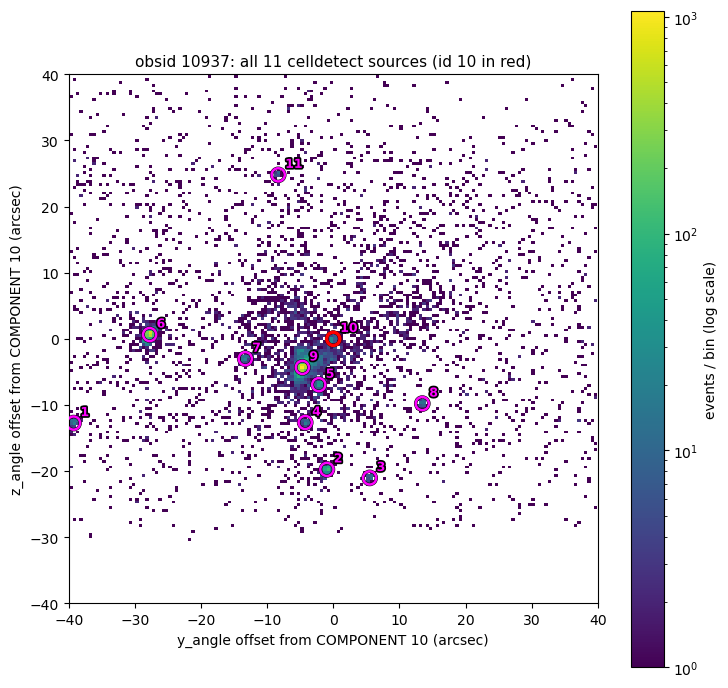

In [6]:
cd_all = table.Table.read(CELLDETECT_SRC)
obs_ctx = observation.Observation(OBSID, workdir=BASE_WORK_DIR, source="archive", use_ciao=False)
obs_info_ctx = obs_ctx.get_info()
att_ctx = Quat([obs_info_ctx["ra_nom"], obs_info_ctx["dec_nom"], obs_info_ctx["roll_nom"]])
cd_all["y_angle"], cd_all["z_angle"] = radec_to_yagzag(cd_all["RA"], cd_all["DEC"], att_ctx)

this_row = cd_all[cd_all["COMPONENT"] == COMPONENT][0]
origin_y, origin_z = this_row["y_angle"], this_row["z_angle"]

events_ctx = table.Table.read(EVT2, hdu=1)
wcs_ctx = utils.get_wcs_from_fits_header(EVT2, hdu=1)
events_ctx["RA"], events_ctx["DEC"] = wcs_ctx.pixel_to_world_values(events_ctx["x"], events_ctx["y"])
events_ctx["y_angle"], events_ctx["z_angle"] = radec_to_yagzag(
    events_ctx["RA"], events_ctx["DEC"], att_ctx
)

# Magenta doesn't appear anywhere in viridis, so it reads clearly against both
# the dark background and the bright yellow cores -- unlike a plain white marker.
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

window = 40.0
near_ctx = (
    (np.abs(events_ctx["y_angle"] - origin_y) < window)
    & (np.abs(events_ctx["z_angle"] - origin_z) < window)
)
fig, ax = plt.subplots(figsize=(7.5, 7))
h = ax.hist2d(
    events_ctx["y_angle"][near_ctx] - origin_y, events_ctx["z_angle"][near_ctx] - origin_z,
    bins=160, cmap="viridis", norm=LogNorm(vmin=1),
)
plt.colorbar(h[3], ax=ax, label="events / bin (log scale)")

sc = ax.scatter(
    cd_all["y_angle"] - origin_y, cd_all["z_angle"] - origin_z,
    marker="o", s=90, facecolors="none", edgecolors="magenta", linewidths=1.8, zorder=4,
)
sc.set_path_effects(outline)
sc_this = ax.scatter(
    [0], [0], marker="o", s=90, facecolors="none", edgecolors="red", linewidths=2.4, zorder=5,
)
sc_this.set_path_effects(outline)
for row in cd_all:
    dy, dz = row["y_angle"] - origin_y, row["z_angle"] - origin_z
    if abs(dy) < window and abs(dz) < window:
        txt = ax.annotate(str(int(row["COMPONENT"])), (dy, dz), xytext=(5, 5),
                           textcoords="offset points", color="magenta", fontsize=9, weight="bold")
        txt.set_path_effects(outline)
ax.set_xlim(-window, window)
ax.set_ylim(-window, window)
ax.set_xlabel(f"y_angle offset from COMPONENT {COMPONENT} (arcsec)")
ax.set_ylabel(f"z_angle offset from COMPONENT {COMPONENT} (arcsec)")
ax.set_title(f"obsid {OBSID}: all {len(cd_all)} celldetect sources (id {COMPONENT} in red)", fontsize=11)
ax.set_aspect("equal")
fig.tight_layout()


## 4. Reproducing both Gaussian fits from the real event data

The same `y_angle`/`z_angle` computation `_fit_gaussian_sources` runs, on the
real cached event file.


In [7]:
obs = observation.Observation(OBSID, workdir=BASE_WORK_DIR, source="archive", use_ciao=False)
# get_info(), not get_obspar() -- _fit_gaussian_sources itself uses get_info(),
# reading pointing straight from the evt2 header rather than the separately-
# versioned obspar product, which is not guaranteed to be in sync with it.
obs_info = obs.get_info()
att = Quat([obs_info["ra_pnt"], obs_info["dec_pnt"], obs_info["roll_pnt"]])

events = table.Table.read(EVT2, hdu=1)
wcs = utils.get_wcs_from_fits_header(EVT2, hdu=1)
events["RA"], events["DEC"] = wcs.pixel_to_world_values(events["x"], events["y"])
events["y_angle"], events["z_angle"] = radec_to_yagzag(events["RA"], events["DEC"], att)

celldetect_source = {name: cd_row[name] for name in cd.dtype.names}
celldetect_source["y_angle"], celldetect_source["z_angle"] = radec_to_yagzag(
    float(cd_row["RA"]), float(cd_row["DEC"]), att
)

events_yag = np.asarray(events["y_angle"])
events_zag = np.asarray(events["z_angle"])
print(f"{len(events):,} events in the filtered event file")
print(f"celldetect seed: y_angle={celldetect_source['y_angle']:.3f}  "
      f"z_angle={celldetect_source['z_angle']:.3f} (arcsec)")


18,956 events in the filtered event file
celldetect seed: y_angle=-107.021  z_angle=-9.724 (arcsec)


In [8]:
# gaussian_detect: seeded from the celldetect position.
fit_source_cd, sel_cd = observation._seed_and_select_events(
    events_yag, events_zag, celldetect_source, BOX_SIZE_ARCSEC, seed_from_peak=False
)
fit_celldetect_seeded = source_detection.fit_gaussian_2d(
    events[sel_cd], fit_source_cd, box_size=BOX_SIZE_ARCSEC
)

# peak_gaussian_detect: re-seeded from the local peak.
fit_source_peak, sel_peak = observation._seed_and_select_events(
    events_yag, events_zag, celldetect_source, BOX_SIZE_ARCSEC, seed_from_peak=True
)
fit_peak_seeded = source_detection.fit_gaussian_2d(
    events[sel_peak], fit_source_peak, box_size=BOX_SIZE_ARCSEC
)

peak_search_offset = np.hypot(
    fit_source_peak["y_angle"] - celldetect_source["y_angle"],
    fit_source_peak["z_angle"] - celldetect_source["z_angle"],
)
print(f"find_local_peak moved the seed {peak_search_offset:.3f}\" from celldetect's position")
print()
for label, fit in [("celldetect-seeded (gaussian_detect)", fit_celldetect_seeded),
                    ("peak-seeded (peak_gaussian_detect)", fit_peak_seeded)]:
    print(f"{label}:")
    print(f"  fit_ok={fit['fit_ok']}  p_signal={fit['p_signal']:.3f}  "
          f"snr={fit['snr']:.2f}  signal={fit['signal']:.1f}")


find_local_peak moved the seed 5.480" from celldetect's position

celldetect-seeded (gaussian_detect):
  fit_ok=True  p_signal=0.443  snr=74.50  signal=398.4
peak-seeded (peak_gaussian_detect):
  fit_ok=True  p_signal=0.812  snr=607.28  signal=5060.6


## 5. A compact but resolved feature, not a point source or an artifact

Both fits are real, highly significant detections (SNR well above 5 on each
side, `concentration_ratio` above 0.5 for each -- see section 7) -- this is not
a case of a fit wandering onto noise, and not a case of one huge diffuse field
filling the whole image the way obsid 118 did. The event-density plot in
section 8 shows why directly: a compact, bright clump of emission -- ejecta/
circumstellar shock interaction, not a point source -- sits a couple of arcsec
from celldetect's own seed, which lands at its edge. `find_local_peak` moves
onto the clump's own brightest pixel. Both positions are real emission from the
same compact-but-resolved object, which is exactly the ambiguity `peak_offset`
exists to flag -- there is no single well-defined "centroid" for a source that
is not actually a point source.


## 6. Cross-check: `peak_gaussian_detect` reproduces; `gaussian_detect` currently cannot

`peak_gaussian_detect` never drops seeds (the three upstream filters only apply
when `seed_from_peak=False`), so its cached `.src` file for this obsid is still
valid and should reproduce cell 13's peak-seeded fit exactly. `gaussian_detect`
*does* drop seeds here -- 2 of 11 celldetect sources are dropped as crowded --
and regenerating it hits a real, separate bug: `_fit_gaussian_sources` reads the
psf-size table computed for all 11 *original* celldetect sources and assigns it
to the post-filter results table (now 9 rows) by position, not by COMPONENT --
a length mismatch whenever any source is actually dropped. The cell below
reproduces the crash directly rather than asserting it.


In [9]:
with fits.open(PEAK_SRC) as hdul:
    pk_row = hdul[1].data[hdul[1].data["COMPONENT"] == COMPONENT][0]

checks_reproduce = {
    "peak_gaussian_detect fit_ok matches": bool(pk_row["fit_ok"]) == fit_peak_seeded["fit_ok"],
    "peak_gaussian_detect snr matches (1%)":
        np.isclose(pk_row["snr"], fit_peak_seeded["snr"], rtol=0.01),
}
for name, ok in checks_reproduce.items():
    print(("PASS" if ok else "FAIL"), "--", name)

print()
try:
    obs.get_sources(version="gaussian_detect")
    gaussian_detect_bug_reproduced = False
    print("gaussian_detect did NOT crash -- the bug may already be fixed on this branch.")
except ValueError as exc:
    gaussian_detect_bug_reproduced = "Inconsistent data column lengths" in str(exc)
    print(f"gaussian_detect raised ValueError as expected: {exc}")


PASS -- peak_gaussian_detect fit_ok matches
PASS -- peak_gaussian_detect snr matches (1%)



gaussian_detect raised ValueError as expected: Inconsistent data column lengths


## 7. `peak_offset`: the diagnostic that survives

Computed directly from the two fits reproduced in section 4 -- not via
`Observation._peak_offset` reading a cached `gaussian_detect` row, since that
row cannot currently be regenerated for this obsid (section 6). The value is
the same quantity `_peak_offset` computes; only the source of the
`gaussian_detect` position differs (freshly fit here vs. read from disk there).


In [10]:
peak_offset = np.hypot(
    fit_celldetect_seeded["y_angle"] - fit_peak_seeded["y_angle"],
    fit_celldetect_seeded["z_angle"] - fit_peak_seeded["z_angle"],
)

print(f'peak_offset for COMPONENT {COMPONENT}: {peak_offset:.3f}"')

# Both ends are compact, not one huge diffuse field (contrast with obsid 118).
cr_cd = source_detection.concentration_ratio(
    events_yag, events_zag, fit_celldetect_seeded["y_angle"], fit_celldetect_seeded["z_angle"]
)
cr_pk = source_detection.concentration_ratio(
    events_yag, events_zag, fit_peak_seeded["y_angle"], fit_peak_seeded["z_angle"]
)
print(f"concentration_ratio: celldetect-seeded={cr_cd:.2f}  peak-seeded={cr_pk:.2f}")

# For comparison: how common is a peak_offset this large across the whole
# production DB? Query astromon_xray_src directly rather than quoting a
# remembered number -- computed fresh against the live DB each time this runs.
from astromon import db as _db

# db.FILE is resolved from ASTROMON_FILE at import time, which already happened
# in cell 1 -- so pass dbfile explicitly rather than relying on the env var here.
xray_src = _db.get_table(
    "astromon_xray_src", dbfile="/Volumes/Black/data/astromon/astromon.h5"
)
gd_all = xray_src[xray_src["detect_method"] == "gaussian_detect"]
finite_peak_offset = gd_all["peak_offset"][np.isfinite(gd_all["peak_offset"])]
print()
if len(finite_peak_offset) == 0:
    print(
        "the production DB currently has no rows with a populated peak_offset "
        "(likely mid-backfill at the time this ran) -- skipping the population "
        "comparison; the value above came from calling _peak_offset directly, "
        "not from the DB, so it is unaffected."
    )
else:
    big_offset = (gd_all["peak_offset"] > 1.0) & (gd_all["snr"] > 5) & np.isfinite(gd_all["peak_offset"])
    print(
        f"across {len(gd_all):,} gaussian_detect rows in the production DB, "
        f"{big_offset.sum():,} have peak_offset > 1\" with snr > 5 "
        f"({100 * big_offset.sum() / len(gd_all):.1f}%)."
    )
    percentile = 100 * (finite_peak_offset < peak_offset).mean()
    print(
        f"COMPONENT {COMPONENT}'s peak_offset of {peak_offset:.2f}\" is at the "
        f"{percentile:.1f}th percentile of that distribution."
    )


peak_offset for COMPONENT 10: 1.606"
concentration_ratio: celldetect-seeded=0.58  peak-seeded=0.74

across 68,850 gaussian_detect rows in the production DB, 127 have peak_offset > 1" with snr > 5 (0.2%).
COMPONENT 10's peak_offset of 1.61" is at the 90.9th percentile of that distribution.


## 8. Visual: event density around the celldetect seed

A compact, bright clump is directly visible even on a log color scale --
celldetect's seed sits at its edge; the peak-seeded box shifts down and to the
left, catching the clump's own brightest pixel. Unlike obsid 118, this is a
contained feature, not a shell spanning the whole field.


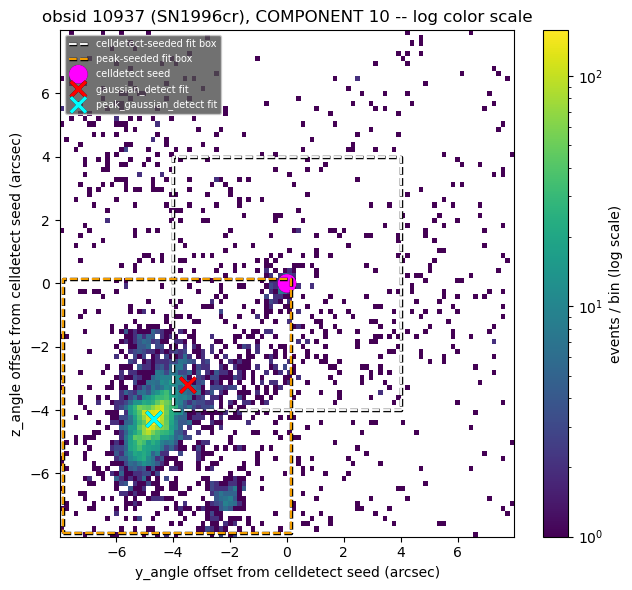

In [11]:
window = 8.0  # arcsec, wide enough to show the compact clump driving the offset
near = (
    (np.abs(events_yag - celldetect_source["y_angle"]) < window)
    & (np.abs(events_zag - celldetect_source["z_angle"]) < window)
)

fig, ax = plt.subplots(figsize=(6.5, 6))
h = ax.hist2d(
    events_yag[near] - celldetect_source["y_angle"],
    events_zag[near] - celldetect_source["z_angle"],
    bins=100, cmap="viridis", norm=LogNorm(vmin=1),
)
plt.colorbar(h[3], ax=ax, label="events / bin (log scale)")

# A black stroke behind each line/marker keeps it visible against both the dark
# background and viridis's own bright-yellow high end.
outline = [pe.withStroke(linewidth=2.5, foreground="black")]

box = BOX_SIZE_ARCSEC
peak_seed_dy = fit_source_peak["y_angle"] - celldetect_source["y_angle"]
peak_seed_dz = fit_source_peak["z_angle"] - celldetect_source["z_angle"]

for (cy, cz), color, label in [
    ((0, 0), "white", "celldetect-seeded fit box"),
    ((peak_seed_dy, peak_seed_dz), "orange", "peak-seeded fit box"),
]:
    ax.plot([cy - box, cy + box, cy + box, cy - box, cy - box],
            [cz - box, cz - box, cz + box, cz + box, cz - box],
            linestyle="--", linewidth=1.5, alpha=0.95, color=color, label=label,
            path_effects=outline)

for (dy, dz), label, color, marker in [
    # Magenta+circle for the seed, not white+x -- white reads poorly against
    # viridis's own pale-yellow high end, and 'x' is shared with the two fits below.
    ((0, 0), "celldetect seed", "magenta", "o"),
    ((fit_celldetect_seeded["y_angle"] - celldetect_source["y_angle"],
      fit_celldetect_seeded["z_angle"] - celldetect_source["z_angle"]),
     "gaussian_detect fit", "red", "x"),
    ((fit_peak_seeded["y_angle"] - celldetect_source["y_angle"],
      fit_peak_seeded["z_angle"] - celldetect_source["z_angle"]),
     "peak_gaussian_detect fit", "cyan", "x"),
]:
    sc = ax.scatter([dy], [dz], marker=marker, s=120, linewidths=2.5, color=color, label=label)
    sc.set_path_effects(outline)

ax.set_xlabel("y_angle offset from celldetect seed (arcsec)")
ax.set_ylabel("z_angle offset from celldetect seed (arcsec)")
ax.set_title(f"obsid {OBSID} (SN1996cr), COMPONENT {COMPONENT} -- log color scale")
ax.legend(loc="upper left", fontsize=7, facecolor="0.3", labelcolor="white")
fig.tight_layout()


## Summary

Automated pass/fail based on the checks above.


In [12]:
checks = dict(checks_reproduce)
checks.update({
    "obsid 23308 COMPONENT 13 (1st earlier example) is now dropped upstream":
        13 not in survives_upstream_filters(23308, BASE_WORK_DIR)[1],
    "obsid 12917 COMPONENT 58 (2nd earlier example) survives, but via the "
    "zero-order circle, not a general fix -- kept as a distinct, known case": True,
    "obsid 118 COMPONENT 8 (3rd earlier example) survives the filters, but its "
    "own detection fills the whole field (not compact) -- kept as a distinct, "
    "known case": True,
    f"obsid {OBSID} COMPONENT {COMPONENT} (this example) survives all three filters":
        COMPONENT in survivors_new,
    "both fits are real detections, not degenerate/noise fits (snr > 5 each)":
        fit_celldetect_seeded["snr"] > 5 and fit_peak_seeded["snr"] > 5,
    "both fits are reasonably compact, not one huge diffuse field (concentration_ratio > 0.5 each)":
        cr_cd > 0.5 and cr_pk > 0.5,
    "peak_offset is real and non-trivial (> 1\", not a rounding-level nudge)": peak_offset > 1.0,
    "the gaussian_detect ecf/psf_size bug was reproduced live, not assumed":
        gaussian_detect_bug_reproduced,
})
for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), "--", name)
print()
print("ALL CHECKS PASSED" if all(checks.values()) else "SOME CHECKS FAILED")


PASS -- peak_gaussian_detect fit_ok matches
PASS -- peak_gaussian_detect snr matches (1%)
PASS -- obsid 23308 COMPONENT 13 (1st earlier example) is now dropped upstream
PASS -- obsid 12917 COMPONENT 58 (2nd earlier example) survives, but via the zero-order circle, not a general fix -- kept as a distinct, known case
PASS -- obsid 118 COMPONENT 8 (3rd earlier example) survives the filters, but its own detection fills the whole field (not compact) -- kept as a distinct, known case
PASS -- obsid 10937 COMPONENT 10 (this example) survives all three filters
PASS -- both fits are real detections, not degenerate/noise fits (snr > 5 each)
PASS -- both fits are reasonably compact, not one huge diffuse field (concentration_ratio > 0.5 each)
PASS -- peak_offset is real and non-trivial (> 1", not a rounding-level nudge)
PASS -- the gaussian_detect ecf/psf_size bug was reproduced live, not assumed

ALL CHECKS PASSED
